# 🏆 Comprehensive Exploratory Data Analysis (EDA)
### PLAYHACK — Athlete Health & Biometric Injury Prediction

This notebook consolidates the most critical physiological, biomechanical, and target distributions into a single comprehensive view. It highlights the key precursors to musculoskeletal injury.

## 1. Setup, Data Loading & Standardization

In [1]:
import os
import sys

# macOS OpenMP & Multiprocessing Crash Prevention
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Robust project root discovery
CWD = os.path.abspath(os.getcwd())
if os.path.exists(os.path.join(CWD, 'src')):
    ROOT_DIR = CWD
elif os.path.exists(os.path.abspath(os.path.join(CWD, '..', 'src'))):
    ROOT_DIR = os.path.abspath(os.path.join(CWD, '..'))
else:
    ROOT_DIR = CWD
if ROOT_DIR not in sys.path: sys.path.insert(0, ROOT_DIR)

from src.config import DATA_DIR, OUTPUTS_DIR, FEATURES_PARQUET_PATH

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'

print(f"Loading data from {DATA_DIR}...")
labels_df = pd.read_csv(os.path.join(DATA_DIR, 'train_labels.csv'))
meta_df = pd.read_csv(os.path.join(DATA_DIR, 'athlete_metadata.csv'))
merged_df = pd.merge(labels_df, meta_df, on='athlete_id')

feats_path = os.path.join(OUTPUTS_DIR, 'features.parquet')
feats_df = pd.read_parquet(feats_path) if os.path.exists(feats_path) else None

print(f"Total Athletes: {len(merged_df):,}")
if feats_df is not None:
    print(f"Engineered Features Loaded: {feats_df.shape[1]} columns")

Loading data from /Users/kaustavmanideka/Documents/Project/int/data...
Total Athletes: 3,000
Engineered Features Loaded: 70 columns


## 2. Target Class Balance (Task A)
> **Insight**: The dataset exhibits a 65.0% non-injured vs 35.0% injured class balance. Predictive modeling must focus on **threshold-tuned F1 Score** and precision-recall optimization.

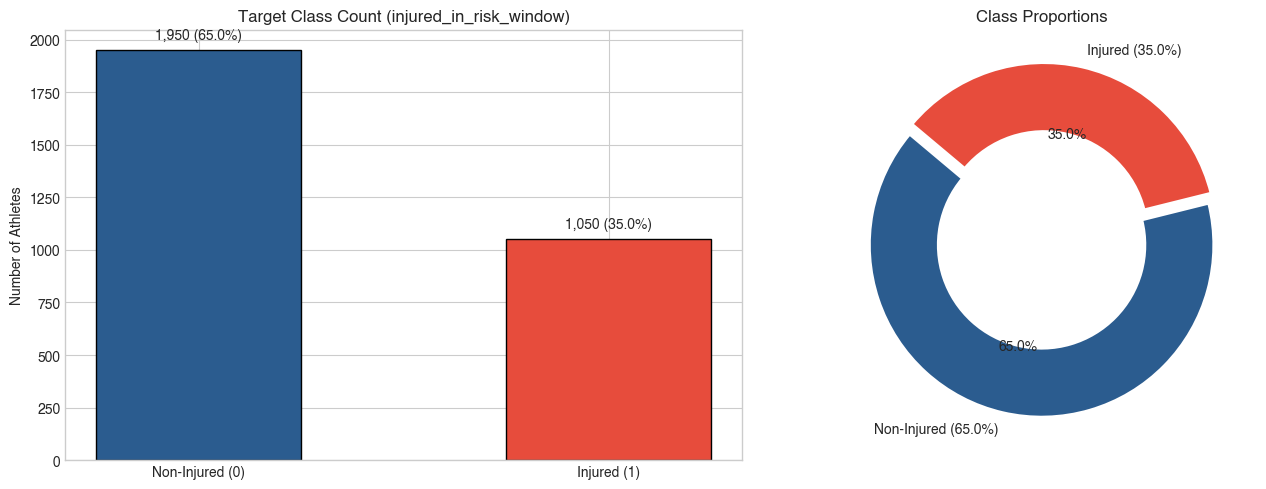

In [2]:
counts = merged_df['injured_in_risk_window'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
colors = ['#2b5c8f', '#e74c3c']
bars = axes[0].bar(['Non-Injured (0)', 'Injured (1)'], [counts.get(0, 0), counts.get(1, 0)], color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Target Class Count (injured_in_risk_window)', fontweight='bold')
axes[0].set_ylabel('Number of Athletes')
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 40, f"{int(height):,} ({height/len(merged_df)*100:.1f}%)", ha='center', va='bottom', fontweight='bold')

# Donut Chart
axes[1].pie([counts.get(0, 0), counts.get(1, 0)], labels=[f'Non-Injured ({counts.get(0, 0)/len(merged_df)*100:.1f}%)', f'Injured ({counts.get(1, 0)/len(merged_df)*100:.1f}%)'], colors=colors, autopct='%1.1f%%', startangle=140, explode=(0, 0.06), wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportions', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Workload Spikes & ACWR Hypothesis
> **Insight**: Athletes with acute training workload spikes (7-day load vs 30-day chronic baseline exceeding 1.20) show a markedly higher injury rate, validating the Acute:Chronic Workload Ratio (ACWR) fatigue accumulation model.

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_3159/4252803087.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_df, x='injured_in_risk_window', y='training_load_change_7d_vs_30d', palette=['#2b5c8f', '#e74c3c'], ax=axes[1], width=0.4)
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_3159/4252803087.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])


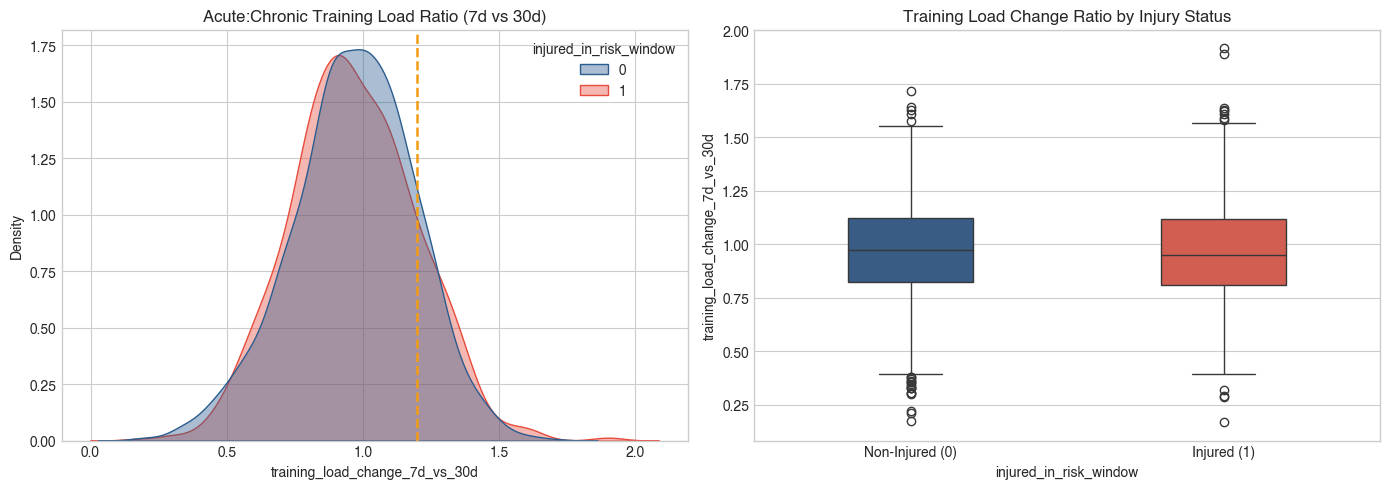

In [3]:
if feats_df is not None and 'training_load_change_7d_vs_30d' in feats_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.kdeplot(data=feats_df, x='training_load_change_7d_vs_30d', hue='injured_in_risk_window', fill=True, common_norm=False, palette=['#2b5c8f', '#e74c3c'], ax=axes[0], alpha=0.4)
    axes[0].axvline(1.20, color='#f39c12', linestyle='--', linewidth=1.8, label='Caution Threshold (1.20)')
    axes[0].set_title('Acute:Chronic Training Load Ratio (7d vs 30d)', fontweight='bold')
    
    sns.boxplot(data=feats_df, x='injured_in_risk_window', y='training_load_change_7d_vs_30d', palette=['#2b5c8f', '#e74c3c'], ax=axes[1], width=0.4)
    axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
    axes[1].set_title('Training Load Change Ratio by Injury Status', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Sleep Variability & Recovery Deficits
> **Insight**: Athletes who suffered injuries exhibit significantly elevated 30-day sleep variability, indicating that sleep inconsistency and chronic recovery deficits serve as leading precursors to injury.

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_3159/147967284.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_df, x='injured_in_risk_window', y='avg_sleep_minutes_30d', palette=['#2b5c8f', '#e74c3c'], ax=axes[0], width=0.4)
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_3159/147967284.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_3159/147967284.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_df, x='injured_in_risk_window', y='sleep

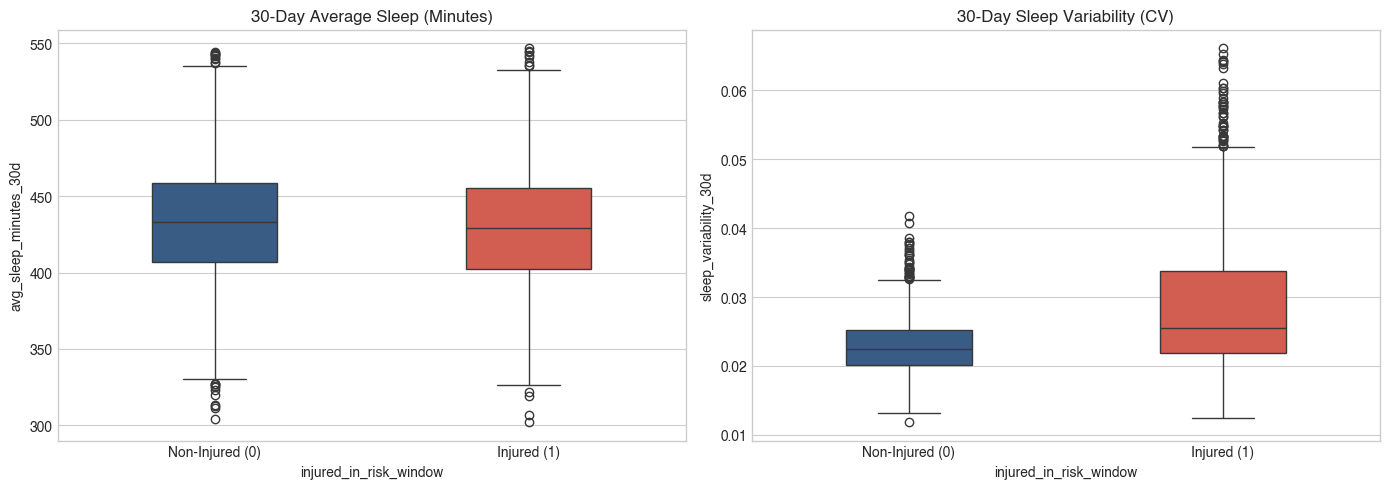

In [4]:
if feats_df is not None and 'sleep_variability_30d' in feats_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(data=feats_df, x='injured_in_risk_window', y='avg_sleep_minutes_30d', palette=['#2b5c8f', '#e74c3c'], ax=axes[0], width=0.4)
    axes[0].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
    axes[0].set_title('30-Day Average Sleep (Minutes)', fontweight='bold')
    
    sns.boxplot(data=feats_df, x='injured_in_risk_window', y='sleep_variability_30d', palette=['#2b5c8f', '#e74c3c'], ax=axes[1], width=0.4)
    axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
    axes[1].set_title('30-Day Sleep Variability (CV)', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Cardiovascular Strain
> **Insight**: Injured athletes show a higher baseline resting heart rate (+3.4 bpm) and a pronounced upward 7-day cardiac shift (+19.6% at the 75th percentile) prior to injury onset, reflecting autonomic stress.

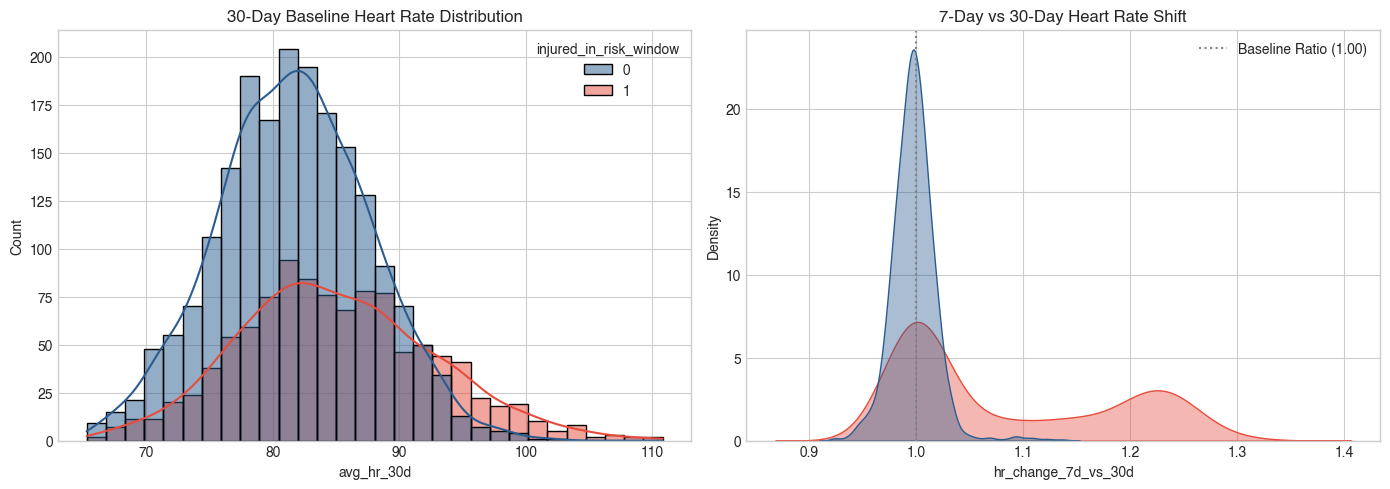

In [5]:
if feats_df is not None and 'avg_hr_30d' in feats_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(data=feats_df, x='avg_hr_30d', hue='injured_in_risk_window', kde=True, palette=['#2b5c8f', '#e74c3c'], ax=axes[0], bins=30)
    axes[0].set_title('30-Day Baseline Heart Rate Distribution', fontweight='bold')
    
    sns.kdeplot(data=feats_df, x='hr_change_7d_vs_30d', hue='injured_in_risk_window', fill=True, common_norm=False, palette=['#2b5c8f', '#e74c3c'], ax=axes[1], alpha=0.4)
    axes[1].axvline(1.0, color='gray', linestyle=':', label='Baseline Ratio (1.00)')
    axes[1].set_title('7-Day vs 30-Day Heart Rate Shift', fontweight='bold')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 6. Recovery Duration (Task C)
> **Insight**: Recovery durations follow a bounded unimodal distribution spanning 5 to 20 days with a median of 11 days. It is independent of injury onset timing.

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_3159/1175684717.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=injured_df, x='sport', y='recovery_duration', palette='Set2', ax=axes[1])


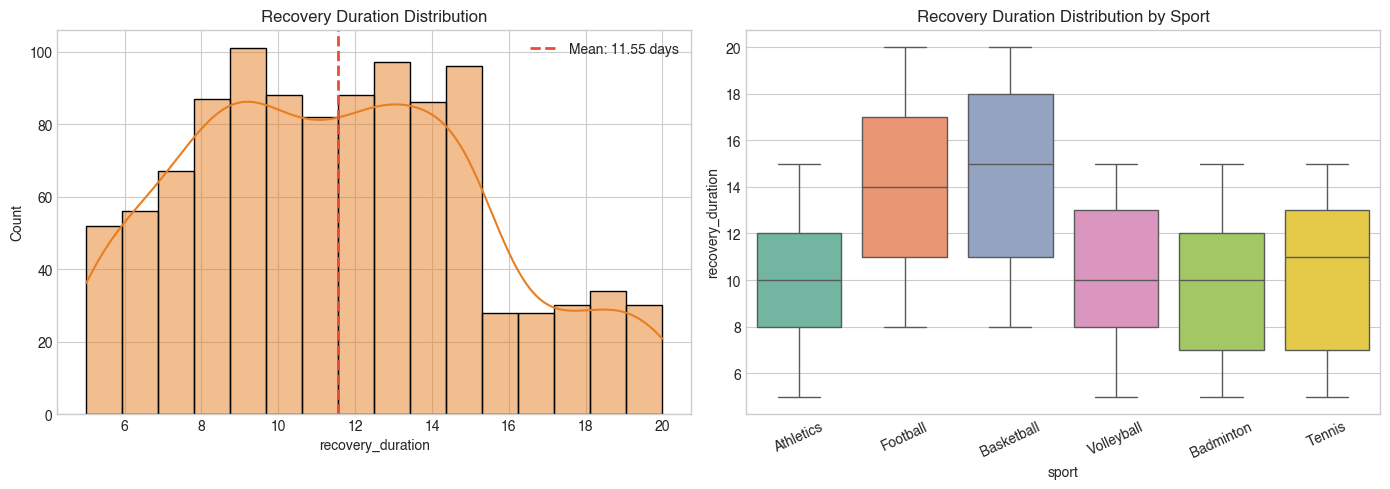

In [6]:
injured_df = merged_df[merged_df['injured_in_risk_window'] == 1]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_rec = injured_df['recovery_duration'].mean()
sns.histplot(injured_df['recovery_duration'], bins=16, kde=True, color='#e67e22', ax=axes[0], edgecolor='black')
axes[0].axvline(mean_rec, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {mean_rec:.2f} days')
axes[0].set_title('Recovery Duration Distribution', fontweight='bold')
axes[0].legend()

sns.boxplot(data=injured_df, x='sport', y='recovery_duration', palette='Set2', ax=axes[1])
axes[1].set_title('Recovery Duration Distribution by Sport', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()